<a href="https://colab.research.google.com/github/Uzayulucay/RP_4q_code/blob/main/2DSquarecyrstal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from collections import Counter

In [ ]:
from sympy import symbols, lambdify, I, conjugate, exp, diff, re, im, expand_complex, expand, simplify, sin, cos, integrate, sqrt,sign

In [ ]:
from sympy import *

In [ ]:
from scipy.optimize import minimize

In [ ]:
nmax = 2

In [ ]:
def combinations(nmax):
  """Takes in the integer bounds and produces lists for all distinct combinations
  of the indices that occur in the fourth order terms, as well as their combinatorial factors.
  """

  n = np.arange(-nmax, nmax + 1, 1)
  allcomb = list(itertools.combinations_with_replacement(n,4)) #generate a list of 4 integers between -nmax and nmax

  #if the sum of integers within a list is 0 add all of its permutations to list1
  list1 = []
  for i in range(len(allcomb)):
    if sum(allcomb[i]) == 0:
      perm = list(set(itertools.permutations(allcomb[i],4)))
      for j in perm:
        list1.append(list(j))


  comb_list1 = []
  comb_list2 = []
  for a in list1:
    for b in list1:
      z = list(zip(a,b)) #combine the lists into 4 vectors with 2 components
      comb_list1.append(tuple(sorted(z))) #ordering the vectors
      comb_list2.append(tuple(sorted(z[:2])+sorted(z[2:])))
      #ordering the first two elements and the last two separately for the mixed 4th order terms

  pos_comb1 = list(set(comb_list1)) #select all the distinct elements
  pos_comb2 = list(set(comb_list2))
  comb_fac1 = []
  comb_fac2 = []

  #count the distinct permutations of an element to find the combinatorial factors
  for i in range(len(pos_comb1)):
    comb_fac1.append(len(set(list(itertools.permutations(pos_comb1[i])))))

  for j in range(len(pos_comb2)):
    comb_fac2.append(len(set(list(itertools.permutations(pos_comb2[j][2:]))))*len(set(list(itertools.permutations(pos_comb2[j][:2])))))
  return pos_comb1, comb_fac1, pos_comb2, comb_fac2

In [ ]:
def comb_three(allcomb,N):
  """Similar to the first part of 'combinations', takes in all possible lists of 4 integers
  and the required N to produce the derivative terms. We require the sum of all elements
  to be not 0, but equal to minus the provided N.
  """

  list1 = []
  for i in range(len(allcomb)):
    if sum(allcomb[i]) == -N:
      perm = list(set(itertools.permutations(allcomb[i],3)))
      for j in perm:
        list1.append(list(j))
  return list1

In [ ]:
def comb_lists(cr1, cr2, cor):
  """Lists are combined in groups of three and only after finding the distinct
  combinations, the fourth elements are added in order to find the combinatorial
  factors.
  """

  comb_list4b = []
  comb_list2b = []
  for a in cr1:
      for b in cr2:
        z = list(zip(a,b))
        comb_list4b.append(tuple(sorted(z)))
        comb_list2b.append(tuple(z[:1]+sorted(z[1:]))) #order the last two separately from the first element

  pos_comb4b = list(set(comb_list4b))
  pos_comb2b = list(set(comb_list2b))

  pc4b = []
  pc2b = []

  for el in pos_comb4b:
    pc4b.append(tuple(cor+list(el)))
    #adding the indices of the coefficient which we take the derivative with respect to

  for l in pos_comb2b:
    pc2b.append(tuple(cor+list(l)))

  return pc4b, pc2b

In [ ]:
def combinations_der(x,nmax):
  """This produces the indices for the derivatives of the fourth order terms and
  their corresponding combinatorial factors.
  Supply x = [(a,b)] """

  n = np.arange(-nmax, nmax + 1, 1)
  allcomb = list(itertools.combinations_with_replacement(n,3)) #this time lists contain 3 elements
  ind = [x[0][0],x[0][1],-x[0][0],-x[0][1]]
  #we need the vector and its inversion to demand complex conjugates are not treated separately

  coord = []
  for i in ind:
    coord.append(comb_three(allcomb, i))


  #derivative wrt the coefficient characterized by x and the complex conjugate of that term
  pc4b1, pc2b1 = comb_lists(coord[0],coord[1],[(x[0][0],x[0][1])])
  pc4b2, pc2b2 = comb_lists(coord[2],coord[3],[(-x[0][0],-x[0][1])])

  comb_fac4b = []
  comb_fac2b = []

  pc4 = list(set(sorted(pc4b1 + pc4b2)))
  pc2 = list(set(pc2b1 + pc2b2))


  prefac4b = []
  prefac2b = []

  for i in range(len(pc4)): #combinatorial factors
    comb_fac4b.append(len(set(list(itertools.permutations(pc4[i])))))
    prefac4b.append(pc4[i].count(pc4[i][0]))


  for i in range(len(pc2)): #combinatorial factors for the mixed terms
    comb_fac2b.append(len(set(list(itertools.permutations(pc2[i][:2]))))*len(set(list(itertools.permutations(pc2[i][2:])))))
    prefac2b.append(pc2[i][:2].count(pc2[i][0]))


  cf4 = np.array(prefac4b) * np.array(comb_fac4b)
  cf2 = np.array(prefac2b) * np.array(comb_fac2b)

  return pc4, cf4, pc2, cf2

In [ ]:
def coef(recomp,imcomp,nmax):
    """This is to symbolically check the arrays.
    """
    Rx = []
    Ix = []

    n = np.append(np.arange(nmax + 1),np.arange(-nmax,0,1))

    for i in n:
      rx = []
      ix = []
      for j in np.arange(nmax + 1):
        rx.append(f"{recomp}_{i}{j}")
        ix.append(f"{imcomp}_{i}{j}")
      Rx.append(np.array(symbols(rx,real = True)))
      Ix.append(np.array(symbols(ix,real = True)))

    Ix[0][0] = 0
    Rx = np.array(Rx)
    Ix = np.array(Ix)

    Rx[-nmax:,:1] = 0
    Ix[-nmax:,:1] = 0
    Posx = Rx + I * Ix
    Negx = Rx - I * Ix
    Negx[0,1:] = np.flip(Negx[0,1:])
    Negx[1:,1:] = np.flip(Negx[1:,1:])

    coefficients = np.append(Rx.reshape(-1),Ix.reshape(-1))
    coefficients2 = np.append(np.append(Rx[:nmax+1,:1],Rx[:,1:].reshape(-1)),np.append(Ix[1:nmax+1,:1],Ix[:,1:].reshape(-1)))
    X = np.array([np.append(Posx[:nmax+1,:1], np.flip(Negx[1:nmax+1,:1]))]).reshape(2*nmax+1,1)
    return coefficients2

In [ ]:
def B4xyz(com,fac,C):
  """Calculation of the 4th order terms that are not mixed (e.g. mx^4).
  Arrays must be arranged in such a way so that the components of each vector
  determine whether we consider a coefficient or its complex conjugate.
  C: An array of length 3. First element is a flat array in case the sign of the second component
  is 0. The proceeding matrices contain elements in the form of A + iB and A - iB respectively.
  com: indices for the 4th order terms.
  fac: combinatorial factors.
  """

  a = []
  for i in range(len(com)):
    b = 1
    for j in range(4):
      b *= C[int(np.sign(com[i][j][1])*1)][com[i][j][0]][com[i][j][1]]
    a.append(b)

  c = a*np.array(fac)

  ad = sum(c)

  return ad #expand(Add(*a))

In [ ]:
def factors(tup,comp):
  """comp is given as either [1,1,1] or [1,i,-i] depending on whether we are taking
  a derivative wrt the real part (A) or the imaginary part(B). Values in comp are
  the prefactors we get after taking the derivative. We treat the cases where a
  coefficients associated vector has a zero as a second component.
  """
  if tup[1] == 0:
    s = comp[int(np.sign(tup[0]))]
  else:
    s = comp[int(np.sign(tup[1]))]

  return s

In [ ]:
def b4xyz(com,fac,C,comp):
  """Calculation of the derivatives of the 4th order non-mixed terms.
  """
  a = []
  for i in range(len(com)):
    b = factors(com[i][0],comp)
    for k in range(1,4):
      b *= C[int(np.sign(com[i][k][1])*1)][com[i][k][0]][com[i][k][1]]
    a.append(b)

  c = a*np.array(fac)

  ad = sum(c)

  return ad #expand(Add(*a))

In [ ]:
def B2xyz(com, fac, C1, C2):
  """Calculation of the 4th order terms that are mixed (e.g. mx^2my^2).
  That is why C1 and C2 contain coefficients of different magnetization components.
  """

  a = []
  for i in range(len(com)):
    b = []
    for j in range(2):
      b.append(C1[int(np.sign(com[i][j][1])*1)][com[i][j][0]][com[i][j][1]])
    for k in range(2,4):
      b.append(C2[int(np.sign(com[i][k][1])*1)][com[i][k][0]][com[i][k][1]])

    a.append(np.prod(b))
  c = a*np.array(fac)

  ad = sum(c)

  return ad

In [ ]:
def b2xyz(com, fac, C1, C2,comp):
  """Calculation of the derivatives of the 4th order mixed terms.
  """
  a = []
  for i in range(len(com)):
    b = factors(com[i][0],comp)*C1[int(np.sign(com[i][1][1])*1)][com[i][1][0]][com[i][1][1]]
    for k in range(2,4):
      b *= C2[int(np.sign(com[i][k][1])*1)][com[i][k][0]][com[i][k][1]]
    a.append(b)

  c = a*np.array(fac)

  ad = sum(c)

  return ad

In [ ]:
def Ar(A,B):
  #Fourier coefficients, complex conjugacy is imposed
  return A + 1j*B, A - 1j*B

In [ ]:
def create_ar(u,nmax):
  L = int((len(u)+1)/2)
  B_array = np.hstack((np.concatenate([np.zeros(1),u[L:][:nmax],np.zeros(nmax)]).reshape(-1,1),u[L:][nmax:].reshape(-1,nmax)))
  A_array = np.hstack((np.concatenate([u[:L][:nmax+1],np.zeros(nmax)]).reshape(-1,1),u[:L][nmax+1:].reshape(-1,nmax)))
  return A_array, B_array #Real and imaginary parts are separated from the given input

In [ ]:
def B4coef(A,B,nmax):
  """These arrays are generated specifically for the functions B4xyz, b4xyz, B2xyz, b2xyz.
  """
  Anew = np.copy(A + 1j*B)
  Bnew = np.copy(A - 1j*B)
  Bnew[0,1:] = np.flip(Bnew[0,1:])
  Bnew[1:,1:] = np.flip(Bnew[1:,1:])

  return [np.array([np.append(Anew[:nmax+1,:1], np.flip(Bnew[1:nmax+1,:1]))]).reshape(2*nmax+1,1),Anew,Bnew]

In [ ]:
def indexes(nmax):
  n = np.append(np.arange(nmax + 1),np.arange(-nmax,0,1))
  indices = []
  for i in n:
    b = []
    for j in np.arange(nmax + 1):
      b.append((i,j))
    indices.append(b)
  indices = np.array(indices)
  return np.vstack((indices[:nmax+1,:1].reshape(-1,2),indices[:,1:].reshape(-1,2)))


In [ ]:
J1 = -7.2/7.2
J2 = 1.05/7.2
J3 = 2.1/7.2
delta1 = 0.01
delta2 = 0
delta3 = 0
Delta1 = 0#-0.1
Delta2 = -0.05 #-0.08
Delta3 = 0#0.03
K = 0#0.06
lamb = 1000
#J4 = -5.1



In [ ]:
def Q_array(s,parameters,fun, nmax,c):
  """In general a reciprocal space vector is written as Q = n1*Q1 + n2*Q2, Q1 and Q2
  being the basis vectors. This function generates the sine and cosines from the
  Fourier transform of the exchange interaction.
  """

  p1 = s[:,:1].reshape(-1)
  p2 = s[:,1:].reshape(-1)
  qx = p1*parameters[0] + p2*parameters[1]
  qy = p1*parameters[2] + p2*parameters[3]
  excx = []
  excy = []


  if fun == "cos":
    for i in range(len(qx)):
      excx.append(np.cos(c*qx[i]))
      excy.append(np.cos(c*qy[i]))
  elif fun == "sin":
    for i in range(len(qx)):
      excx.append(np.sin(c*qx[i]))
      excy.append(np.sin(c*qy[i]))

  return np.array(excx), np.array(excy)


In [ ]:
def exchange(SxSx,SySy,SzSz,SxSy,param,nmax):
  s = indexes(nmax)
  cosqx, cosqy = Q_array(s,param,"cos",nmax,1)
  cos2qx, cos2qy = Q_array(s,param,"cos",nmax,2)
  sinqx, sinqy = Q_array(s,param,"sin",nmax,1)

  Exchange = 0.5*(
      np.dot((2*J1 + Delta1) * cosqx + (2*J1 - Delta1) * cosqy
      + 4*J2 * cosqx*cosqy + (2*J3 + Delta3) * cos2qx + (2*J3 - Delta3) * cos2qy,SxSx)
      + np.dot((2*J1 - Delta1) * cosqx + (2*J1 + Delta1) * cosqy
      + 4*J2 * cosqx*cosqy + (2*J3 - Delta3) * cos2qx + (2*J3 + Delta3) * cos2qy, SySy)
      - 2*Delta2*np.dot(sinqx*sinqy,SxSy)
      + np.dot(2*(J1 + delta1)*(cosqx + cosqy) + 4*(J2 + delta2)*cosqx*cosqy + 2*(J3 + delta3)*(cos2qx + cos2qy) + K*np.ones(len(cosqx)), SzSz)
  )
  return Exchange

In [ ]:
def energy(parameters):

  arx, ary, arz = np.split(parameters[4:],3)
  Ax, Bx = create_ar(arx,nmax); Ay, By = create_ar(ary,nmax); Az, Bz = create_ar(arz,nmax)

  com = combinations(nmax)

  Posx, Negx = Ar(Ax,Bx)
  Posy, Negy = Ar(Ay,By)
  Posz, Negz = Ar(Az,Bz)

  sxsx = Posx*Negx
  sysy = Posy*Negy
  szsz = Posz*Negz

  #SqS-q terms
  SxSx = np.append(sxsx[0,0],2*np.append(sxsx[1:nmax+1,:1], sxsx[:,1:].reshape(-1)))
  SySy = np.append(sysy[0,0],2*np.append(sysy[1:nmax+1,:1], sysy[:,1:].reshape(-1)))
  SzSz = np.append(szsz[0,0],2*np.append(szsz[1:nmax+1,:1], szsz[:,1:].reshape(-1)))


  coefmatx = B4coef(Ax,Bx,nmax)
  coefmaty = B4coef(Ay,By,nmax)
  coefmatz = B4coef(Az,Bz,nmax)

  S4x = B4xyz(com[0],com[1],coefmatx)
  S4y = B4xyz(com[0],com[1],coefmaty)
  S4z = B4xyz(com[0],com[1],coefmatz)

  S2xy = B2xyz(com[2],com[3],coefmatx,coefmaty)
  S2yz = B2xyz(com[2],com[3],coefmaty,coefmatz)
  S2zx = B2xyz(com[2],com[3],coefmatz,coefmatx)

  s = indexes(nmax)

  SxSy = (
    np.append(Posx[:nmax+1,:1], Posx[:,1:].reshape(-1))*np.append(Negy[:nmax+1,:1], Negy[:,1:].reshape(-1))
    + np.append(Posy[:nmax+1,:1], Posy[:,1:].reshape(-1))*np.append(Negx[:nmax+1,:1], Negx[:,1:].reshape(-1))
  )
  Energy = exchange(SxSx,SySy,SzSz,SxSy,parameters[:4],nmax) + lamb*(S4x + S4y + S4z + 2*(S2xy + S2yz + S2zx) - 2 * sum(SxSx + SySy + SzSz) + 1)
  return np.real(Energy)

In [ ]:
def der_q12x(SxSx,SySy,SzSz,SxSy,param,ch):
  """derivatives wrt q1x and q2x"""
  s = indexes(nmax)
  cosqx, cosqy = Q_array(s,param,"cos",nmax,1)
  sinqx, sinqy = Q_array(s,param,"sin",nmax,1)
  sin2qx, sin2qy = Q_array(s,param,"sin",nmax,2)
  if ch == 1:
    p = s[:,:1].reshape(-1)
  elif ch == 2:
    p = s[:,1:].reshape(-1)

  dExchange = 0.5*(
    np.dot(-(2*J1 + Delta1)*sinqx +
     - 4*J2*sinqx*cosqy - 2*(2*J3 + Delta3)*sin2qx,SxSx*p)
    + np.dot(-(2*J1 - Delta1)*sinqx
    - 4*J2*sinqx*cosqy - 2*(2*J3 - Delta3)*sin2qx, SySy*p)
    - 2*Delta2*np.dot(cosqx*sinqy,SxSy*p)
    + np.dot(-2*(J1 + delta1)*sinqx - 4*(J2 + delta2)*sinqx*cosqy - 4*(J3 + delta3)*sin2qx, SzSz*p)
  )
  return dExchange

In [ ]:
def der_q12y(SxSx,SySy,SzSz,SxSy,param,ch):
  """derivatives wrt q1y and q2y
  ch: selects q1y or q2y
  """
  s = indexes(nmax)
  cosqx, cosqy = Q_array(s,param,"cos",nmax,1)
  sinqx, sinqy = Q_array(s,param,"sin",nmax,1)
  sin2qx, sin2qy = Q_array(s,param,"sin",nmax,2)


  if ch == 1:
    p = s[:,:1].reshape(-1)
  elif ch == 2:
    p = s[:,1:].reshape(-1)

  dExchange = 0.5*(
      np.dot(-(2*J1 - Delta1)*sinqy
    - 4*J2*cosqx*sinqy - 2*(2*J3 - Delta3)*sin2qy,SxSx*p)
    + np.dot(-(2*J1 + Delta1)*sinqy
    - 4 *J2*cosqx*sinqy - 2*(2*J3 + Delta3)*sin2qy, SySy*p)
    - 2*Delta2*np.dot(sinqx*cosqy,SxSy*p)
    + np.dot(-2*(J1 + delta1)*sinqy - 4*(J2 + delta2)*cosqx*sinqy - 4*(J3 + delta3)*sin2qy, SzSz*p)
  )
  return dExchange


In [ ]:
def derivatives(indices, parameters, comp):
  """derivatives of energy wrt the Fourier coefficients. The derivative for the
  coefficient associated with (0,0) is treated differently since it has no imaginary part"""
  arx, ary, arz = np.split(parameters[4:],3)
  Ax, Bx = create_ar(arx,nmax); Ay, By = create_ar(ary,nmax); Az, Bz = create_ar(arz,nmax)

  Posx, Negx = Ar(Ax,Bx)
  Posy, Negy = Ar(Ay,By)
  Posz, Negz = Ar(Az,Bz)

  coefmatx = B4coef(Ax,Bx,nmax)
  coefmaty = B4coef(Ay,By,nmax)
  coefmatz = B4coef(Az,Bz,nmax)

  cosqx, cosqy = Q_array(indices,parameters[:4],"cos",nmax,1)
  cos2qx, cos2qy = Q_array(indices,parameters[:4],"cos",nmax,2)
  sinqx, sinqy = Q_array(indices,parameters[:4],"sin",nmax,1)
  sin2qx, sin2qy = Q_array(indices,parameters[:4],"sin",nmax,2)

  dEx = []
  dEy = []
  dEz = []
  for i in range(len(indices)):
    indx = (indices[i,0],indices[i,1])
    cod = combinations_der([indx],nmax)
    S4x = b4xyz(cod[0], cod[1],coefmatx,comp)
    S4y = b4xyz(cod[0], cod[1],coefmaty,comp)
    S4z = b4xyz(cod[0], cod[1],coefmatz,comp)

    S2xy = b2xyz(cod[2], cod[3],coefmatx, coefmaty,comp)
    S2xz = b2xyz(cod[2], cod[3],coefmatx, coefmatz,comp)
    S2yx = b2xyz(cod[2], cod[3],coefmaty, coefmatx,comp)
    S2yz = b2xyz(cod[2], cod[3],coefmaty, coefmatz,comp)
    S2zx = b2xyz(cod[2], cod[3],coefmatz, coefmatx,comp)
    S2zy = b2xyz(cod[2], cod[3],coefmatz, coefmaty,comp)

    if indx == (0,0):
      dEx.append(lamb*(S4x + 2*(S2xy + S2xz) - 4 * Posx[indx]) + 4.0*(J1 +
      J2 + J3)*Posx[0,0])
      dEy.append(lamb*(S4y + 2*(S2yx + S2yz) - 4 * Posy[indx]) + 4.0*(J1 +
      J2 + J3)*Posy[0,0])
      dEz.append(lamb*(S4z + 2*(S2zy + S2zx) - 4 * Posz[indx])
      + 0.5*(8*(J1 + delta1 + J2 + delta2 + J3 + delta3) + 2.0*K)*Posz[0,0])
    else:
      dEx.append(lamb *(S4x + 2*(S2xy + S2xz) - 4 * comp[-1]*(Posx[indx]) - 4 * comp[1]*(Negx[indx]))
      + 0.5*(((2*J1 + Delta1) * cosqx[i] + (2*J1 - Delta1) * cosqy[i]
      + 4*J2 * cosqx[i]*cosqy[i] + (2*J3 + Delta3) * cos2qx[i] + (2*J3 - Delta3) * cos2qy[i])*2*(comp[-1]*Posx[indx] + comp[1]*Negx[indx])
      - 2*Delta2*sinqx[i]*sinqy[i]*(comp[-1]*Posy[indx] + comp[1]*Negy[indx])))

      dEy.append(lamb*(S4y + 2*(S2yx + S2yz) - 4 * comp[-1]*(Posy[indx]) - 4 * comp[1]*(Negy[indx]))
      + 0.5*(((2*J1 - Delta1) * cosqx[i] + (2*J1 + Delta1) * cosqy[i]
      + 4*J2 * cosqx[i]*cosqy[i] + (2*J3 - Delta3) * cos2qx[i] + (2*J3 + Delta3) * cos2qy[i])*2*(comp[-1]*Posy[indx] + comp[1]*Negy[indx])
      - 2*Delta2*sinqx[i]*sinqy[i]*(comp[-1]*Posx[indx] + comp[1]*Negx[indx])))

      dEz.append(lamb*(S4z + 2*(S2zy + S2zx) - 4 * comp[-1]*(Posz[indx]) - 4 * comp[1]*(Negz[indx]))
      + 0.5*((2*(J1 + delta1)*(cosqx[i] + cosqy[i]) + 4*(J2 + delta2)*cosqx[i]*cosqy[i]
      + 2*(J3 + delta3)*(cos2qx[i] + cos2qy[i]) + 1.0*K)*2*(comp[-1]*Posz[indx] + comp[1]*Negz[indx])))
  return np.array(dEx), np.array(dEy), np.array(dEz)

In [ ]:
def der(parameters):
  """The full gradient function"""
  arx, ary, arz = np.split(parameters[4:],3)
  Ax, Bx = create_ar(arx,nmax); Ay, By = create_ar(ary,nmax); Az, Bz = create_ar(arz,nmax)

  com = combinations(nmax)

  Posx, Negx = Ar(Ax,Bx)
  Posy, Negy = Ar(Ay,By)
  Posz, Negz = Ar(Az,Bz)

  sxsx = Posx*Negx
  sysy = Posy*Negy
  szsz = Posz*Negz


  SxSx = np.append(sxsx[0,0],2*np.append(sxsx[1:nmax+1,:1], sxsx[:,1:].reshape(-1)))
  SySy = np.append(sysy[0,0],2*np.append(sysy[1:nmax+1,:1], sysy[:,1:].reshape(-1)))
  SzSz = np.append(szsz[0,0],2*np.append(szsz[1:nmax+1,:1], szsz[:,1:].reshape(-1)))


  SxSy = (
    np.append(Posx[:nmax+1,:1], Posx[:,1:].reshape(-1))*np.append(Negy[:nmax+1,:1], Negy[:,1:].reshape(-1))
    + np.append(Posy[:nmax+1,:1], Posy[:,1:].reshape(-1))*np.append(Negx[:nmax+1,:1], Negx[:,1:].reshape(-1))
  )

  d_q1x = np.array([der_q12x(SxSx,SySy,SzSz,SxSy,parameters[:4],1)])
  d_q2x = np.array([der_q12x(SxSx,SySy,SzSz,SxSy,parameters[:4],2)])
  d_q1y = np.array([der_q12y(SxSx,SySy,SzSz,SxSy,parameters[:4],1)])
  d_q2y = np.array([der_q12y(SxSx,SySy,SzSz,SxSy,parameters[:4],2)])
  Eax, Eay, Eaz = derivatives(indexes(nmax),parameters,[1,1,1])
  Ebx, Eby, Ebz= derivatives(indexes(nmax)[1:],parameters,[1,1j,-1j])
  return np.real(np.concatenate([d_q1x,d_q2x,d_q1y,d_q2y,Eax,Ebx,Eay,Eby,Eaz,Ebz]))

In [ ]:
Q1_x, Q2_x, Q1_y, Q2_y = symbols("Q1_x Q2_x Q1_y Q2_y")

In [ ]:
param_sym1 = np.concatenate((np.array([Q1_x, Q2_x, Q1_y, Q2_y]),coef("A_x","B_x",1),coef("A_y","B_y",1),coef("A_z","B_z",1)))
param_sym1

array([Q1_x, Q2_x, Q1_y, Q2_y, A_x_00, A_x_10, A_x_01, A_x_11, A_x_-11,
       B_x_10, B_x_01, B_x_11, B_x_-11, A_y_00, A_y_10, A_y_01, A_y_11,
       A_y_-11, B_y_10, B_y_01, B_y_11, B_y_-11, A_z_00, A_z_10, A_z_01,
       A_z_11, A_z_-11, B_z_10, B_z_01, B_z_11, B_z_-11], dtype=object)

In [ ]:
param_sym2 = np.concatenate((np.array([Q1_x, Q2_x, Q1_y, Q2_y]),coef("A_x","B_x",2),coef("A_y","B_y",2),coef("A_z","B_z",2)))
len(param_sym2)

79

In [ ]:
param_sym3 = np.concatenate((np.array([Q1_x, Q2_x, Q1_y, Q2_y]),coef("A_x","B_x",3),coef("A_y","B_y",3),coef("A_z","B_z",3)))
len(param_sym3)

151

In [ ]:
param_sym4 = np.concatenate((np.array([Q1_x, Q2_x, Q1_y, Q2_y]),coef("A_x","B_x",4),coef("A_y","B_y",4),coef("A_z","B_z",4)))
len(param_sym4)

247

In [ ]:
def input_arrays(param,nmax):
  arx, ary, arz = np.split(param[4:],3)
  Ax, Bx = create_ar(arx,nmax); Ay, By = create_ar(ary,nmax); Az, Bz = create_ar(arz,nmax)
  return Ax,Bx,Ay,By,Az,Bz

In [ ]:
in_ar = input_arrays(np.zeros(31),1)
in_ar[1][0,1] = -0.1 ;in_ar[1][1,0] = -0.3
in_ar[3][0,1] = -0.1; in_ar[3][1,0] = 0.3
in_ar[4][1,0] = 0.5
in_arrays = []
for i in range(3):
  in_arrays.append(np.hstack((in_ar[2*i][:nmax+1,:1].reshape(-1),in_ar[2*i][:,1:].reshape(-1))))
  in_arrays.append(np.hstack((in_ar[2*i+1][1:nmax+1,:1].reshape(-1),in_ar[2*i+1][:,1:].reshape(-1))))
inp_1har = np.concatenate((in_arrays))
input_9harmonics = np.concatenate((np.array([0.8,0.8,0.8,-0.8]),inp_1har))
input_9harmonics

array([ 0.8,  0.8,  0.8, -0.8,  0. ,  0. ,  0. ,  0. ,  0. ,  0. , -0.3,
        0. , -0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0.3,
        0. , -0.1,  0. ,  0. ,  0. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ])

In [ ]:
x = np.linspace(0.7,1,200)
EN = []
for i in range(len(x)):
  EN.append(energy(np.concatenate((np.array([0.8278209,x[i],0.8278209,-x[i]]),inp_1har))))
plt.plot(x,EN)


ValueError: cannot reshape array of size 2 into shape (3)

In [ ]:
x[np.where(EN == np.min(EN))]

ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
output_9harmonics = np.array([ 0.82782008,  0.83097337,  0.82782008, -0.83097337,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        , -0.37531695,
       -0.02603001,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.37531364, -0.02603028,
        0.        ,  0.        ,  0.        ,  0.52949847,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ])

In [ ]:
in_ar = input_arrays(np.zeros(79),2)
in_ar[1][0,1] = -0.02603001; in_ar[1][1,0] = -0.37531695
in_ar[3][0,1] = -0.02603001; in_ar[3][1,0] = 0.37531695
in_ar[4][1,0] = 0.52949847
in_arrays = []
for i in range(3):
  in_arrays.append(np.hstack((in_ar[2*i][:nmax+1,:1].reshape(-1),in_ar[2*i][:,1:].reshape(-1))))
  in_arrays.append(np.hstack((in_ar[2*i+1][1:nmax+1,:1].reshape(-1),in_ar[2*i+1][:,1:].reshape(-1))))
inp_2har = np.concatenate((in_arrays))
input_25harmonics = np.concatenate((np.array([0.82782008,  0.83097337,  0.82782008, -0.83097337]),inp_2har))
input_25harmonics

array([ 0.82782008,  0.83097337,  0.82782008, -0.83097337,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.37531695,  0.        , -0.02603001,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.37531695,  0.        , -0.02603001,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.52949847,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [ ]:
output_25harmonics = np.array([ 8.27706748e-01,  8.22267653e-01,  8.27706748e-01, -8.22267731e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -3.67900143e-01,  0.00000000e+00, -1.10161208e-01,
        0.00000000e+00,  0.00000000e+00, -3.74107392e-03, -1.11597030e-03,
        0.00000000e+00, -1.11561416e-03,  0.00000000e+00,  0.00000000e+00,
        3.74094838e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.67905208e-01,  0.00000000e+00,
       -1.10160132e-01,  0.00000000e+00,  0.00000000e+00,  3.74116617e-03,
       -1.11575035e-03,  0.00000000e+00, -1.11631389e-03,  0.00000000e+00,
        0.00000000e+00, -3.74110064e-03,  0.00000000e+00,  5.18033534e-01,
        0.00000000e+00, -7.21194070e-07,  0.00000000e+00,  0.00000000e+00,
        5.75143095e-03,  1.81945828e-07,  0.00000000e+00,  4.92114198e-07,
        0.00000000e+00,  0.00000000e+00,  5.75138674e-03,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [ ]:
input_arrays(output_25harmonics,2)

(array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]),
 array([[ 0.        , -0.11016121,  0.        ],
        [-0.36790014,  0.        , -0.00374107],
        [ 0.        , -0.00111597,  0.        ],
        [ 0.        , -0.00111561,  0.        ],
        [ 0.        ,  0.        ,  0.00374095]]),
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]),
 array([[ 0.        , -0.11016013,  0.        ],
        [ 0.36790521,  0.        ,  0.00374117],
        [ 0.        , -0.00111575,  0.        ],
        [ 0.        , -0.00111631,  0.        ],
        [ 0.        ,  0.        , -0.0037411 ]]),
 array([[ 0.00000000e+00, -7.21194070e-07,  0.00000000e+00],
        [ 5.18033534e-01,  0.00000000e+00,  5.75143095e-03],
        [ 0.00000000e+00,  1.81945828e-07,  0.00000000e+00],
        [ 0.00000000e+00,  4.92114198e-07,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e

In [ ]:
in_ar = input_arrays(np.zeros(151),3)
in_ar[1][-2,1] = -1.11631389e-03; in_ar[1][2,1] = -1.11631389e-03; in_ar[1][1,2] = -3.74116617e-03; in_ar[1][-1,2] =  3.74110064e-03; in_ar[1][0,1] = -1.10161208e-01; in_ar[1][1,0] = -3.67900143e-01
in_ar[3][-2,1] = -1.11631389e-03; in_ar[3][2,1] = -1.11631389e-03; in_ar[3][1,2] =  3.74116617e-03; in_ar[3][-1,2] = -3.74110064e-03; in_ar[3][0,1] = -1.10161208e-01; in_ar[3][1,0] = 3.67905208e-01
in_ar[4][-2,1] = 4.92114198e-07; in_ar[4][2,1] = 1.81945828e-07; in_ar[4][0,1] = -7.21194070e-07;in_ar[4][1,0] = 5.18033534e-01; in_ar[4][1,2] = 5.75143095e-03; in_ar[4][-1,2] = 5.75143095e-03
in_arrays = []
for i in range(3):
  in_arrays.append(np.hstack((in_ar[2*i][:nmax+1,:1].reshape(-1),in_ar[2*i][:,1:].reshape(-1))))
  in_arrays.append(np.hstack((in_ar[2*i+1][1:nmax+1,:1].reshape(-1),in_ar[2*i+1][:,1:].reshape(-1))))
inp_3har = np.concatenate((in_arrays))
input_49harmonics = np.concatenate((np.array([8.27706748e-01,  8.22267653e-01,  8.27706748e-01, -8.22267731e-01]),inp_3har))
input_49harmonics

array([ 8.27706748e-01,  8.22267653e-01,  8.27706748e-01, -8.22267731e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -3.67900143e-01,  0.00000000e+00,  0.00000000e+00,
       -1.10161208e-01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -3.74116617e-03,  0.00000000e+00, -1.11631389e-03,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -1.11631389e-03,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  3.74110064e-03,
        0.00000000e+00,  

In [ ]:
in_ar = input_arrays(np.zeros(247))
in_ar[1][-2,3] = -1.78982683e-05; in_ar[1][-3,2] = 1.04304223e-04; in_ar[1][3,2] = -1.04304223e-04; in_ar[1][3,0] = -1.52299124e-03; in_ar[1][2,3] = -1.78982683e-05; in_ar[1][0,3] = -4.06991519e-04; in_ar[1][-2,1] = -1.09913004e-03; in_ar[1][2,1] = -1.09913004e-03; in_ar[1][1,2] = -3.70392048e-03; in_ar[1][-1,2] = 3.70392048e-03; in_ar[1][0,1] = -1.05632085e-01; in_ar[1][1,0] = -3.58910913e-01
in_ar[3][-2,3] = -1.78982683e-05; in_ar[3][-3,2] = -1.04304223e-04; in_ar[3][3,2] = 1.04304223e-04; in_ar[3][3,0] = 1.52299124e-03; in_ar[3][2,3] = -1.78982683e-05; in_ar[3][0,3] = -4.06991519e-04; in_ar[3][-2,1] = -1.09913004e-03; in_ar[3][2,1] = -1.09913004e-03; in_ar[3][1,2] = 3.70392048e-03; in_ar[3][-1,2] = -3.70392048e-03; in_ar[3][0,1] = -1.05632085e-01; in_ar[3][1,0] = 3.58910913e-01
in_ar[4][3,0] = 2.16962459e-03; in_ar[4][-3,2] = 1.48154466e-04 ;in_ar[4][3,2] = 1.48154466e-04; in_ar[4][1,0] = 5.01651770e-01; in_ar[4][1,2] = 5.40593314e-03; in_ar[4][-1,2] = 5.40593314e-03
in_arrays = []
for i in range(3):
  in_arrays.append(np.hstack((in_ar[2*i][:nmax+1,:1].reshape(-1),in_ar[2*i][:,1:].reshape(-1))))
  in_arrays.append(np.hstack((in_ar[2*i+1][1:nmax+1,:1].reshape(-1),in_ar[2*i+1][:,1:].reshape(-1))))
inp_4har = np.concatenate((in_arrays))
input_81harmonics = np.concatenate((np.array([ 8.27674359e-01,  8.21998126e-01,  8.27674359e-01, -8.21998126e-01]),inp_4har))
input_81harmonics

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 5 and the array at index 1 has size 19

In [ ]:
in_harmo = np.array([ 8.27818444e-01,  8.30973042e-01,  8.27818444e-01, -8.30973042e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -3.53256312e-01,  0.00000000e+00, -2.49210390e-02,
        0.00000000e+00,  0.00000000e+00, -2.05928636e-04, -3.96131167e-04,
        0.00000000e+00, -3.96131167e-04,  0.00000000e+00,  0.00000000e+00,
        2.05928636e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.53256312e-01,  0.00000000e+00,
       -2.49210390e-02,  0.00000000e+00,  0.00000000e+00,  2.05928636e-04,
       -3.96131167e-04,  0.00000000e+00, -3.96131167e-04,  0.00000000e+00,
        0.00000000e+00, -2.05928636e-04,  0.00000000e+00,  4.99493848e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        3.30961391e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.30961391e-04,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [ ]:
res = minimize(energy, x0 = in_harmo ,method = "BFGS", jac = der)
output = res.x
res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -1.2696097815447174
        x: [ 8.277e-01  8.228e-01 ...  0.000e+00  0.000e+00]
      nit: 113
      jac: [-1.483e-10  3.765e-08 ...  0.000e+00  0.000e+00]
 hess_inv: [[ 1.000e+00  3.697e-02 ...  0.000e+00  0.000e+00]
            [ 3.697e-02  4.025e+01 ...  0.000e+00  0.000e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]]
     nfev: 141
     njev: 141

In [ ]:
output_harmonics = np.real(output)
output_harmonics

array([ 8.27724075e-01,  8.22837042e-01,  8.27724076e-01, -8.22835968e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -3.47436150e-01,  0.00000000e+00, -9.51807909e-02,
        0.00000000e+00,  0.00000000e+00, -3.12849202e-03, -9.51864916e-04,
        0.00000000e+00, -9.51825607e-04,  0.00000000e+00,  0.00000000e+00,
        3.12850294e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.47436626e-01,  0.00000000e+00,
       -9.51806577e-02,  0.00000000e+00,  0.00000000e+00,  3.12849795e-03,
       -9.51861182e-04,  0.00000000e+00, -9.51823197e-04,  0.00000000e+00,
        0.00000000e+00, -

In [ ]:
energy(output_harmonics)

np.float64(-1.2696097815452982)

In [ ]:
output_49harmonics = np.array([ 8.27642628e-01,  8.22277005e-01,  8.27642629e-01, -8.22277045e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -3.69394758e-01,  0.00000000e+00, -1.56509190e-03,
       -1.10695105e-01,  0.00000000e+00, -4.50017013e-04,  0.00000000e+00,
       -3.85096551e-03,  0.00000000e+00, -1.14881044e-03,  0.00000000e+00,
       -2.38085943e-05,  0.00000000e+00, -1.14064339e-04,  0.00000000e+00,
        0.00000000e+00,  1.12854348e-04,  0.00000000e+00, -1.14868573e-03,
        0.00000000e+00, -2.40506076e-05,  0.00000000e+00,  3.85109883e-03,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.69394475e-01,  0.00000000e+00,
        1.56512229e-03, -1.10694125e-01,  0.00000000e+00, -4.50044496e-04,
        0.00000000e+00,  3.85114041e-03,  0.00000000e+00, -1.14826425e-03,
        0.00000000e+00, -2.39314263e-05,  0.00000000e+00,  1.13602195e-04,
        0.00000000e+00,  0.00000000e+00, -1.14679098e-04,  0.00000000e+00,
       -1.14839979e-03,  0.00000000e+00, -2.37580096e-05,  0.00000000e+00,
       -3.85096952e-03,  0.00000000e+00,  0.00000000e+00,  5.15669263e-01,
        0.00000000e+00,  2.22606864e-03,  8.39218672e-08,  0.00000000e+00,
        1.76934603e-08,  0.00000000e+00,  5.61463539e-03,  0.00000000e+00,
        2.88646352e-07,  0.00000000e+00,  8.67837484e-09,  0.00000000e+00,
        1.64862521e-04,  0.00000000e+00,  0.00000000e+00,  1.64764035e-04,
        0.00000000e+00, -5.75189017e-07,  0.00000000e+00,  1.83482112e-07,
        0.00000000e+00,  5.61478575e-03,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [ ]:
output_81harmonics = np.array([ 8.27670835e-01,  8.21998671e-01,  8.27670835e-01, -8.21998671e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -3.58907382e-01,  0.00000000e+00, -1.52388258e-03,
        0.00000000e+00, -1.05641033e-01,  0.00000000e+00, -4.54404566e-04,
        0.00000000e+00,  0.00000000e+00, -3.70187363e-03,  0.00000000e+00,
       -1.36599510e-05, -1.09850957e-03,  0.00000000e+00, -2.31820616e-05,
        0.00000000e+00,  0.00000000e+00, -1.02811737e-04,  0.00000000e+00,
       -1.69270201e-06, -8.62695543e-06,  0.00000000e+00, -7.86879547e-07,
        0.00000000e+00, -8.62695543e-06,  0.00000000e+00, -7.86879547e-07,
        0.00000000e+00,  0.00000000e+00,  1.02811737e-04,  0.00000000e+00,
        1.69270201e-06, -1.09850957e-03,  0.00000000e+00, -2.31820616e-05,
        0.00000000e+00,  0.00000000e+00,  3.70187363e-03,  0.00000000e+00,
        1.36599510e-05,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.58907382e-01,  0.00000000e+00,
        1.52388258e-03,  0.00000000e+00, -1.05641033e-01,  0.00000000e+00,
       -4.54404566e-04,  0.00000000e+00,  0.00000000e+00,  3.70187363e-03,
        0.00000000e+00,  1.36599510e-05, -1.09850957e-03,  0.00000000e+00,
       -2.31820616e-05,  0.00000000e+00,  0.00000000e+00,  1.02811737e-04,
        0.00000000e+00,  1.69270201e-06, -8.62695543e-06,  0.00000000e+00,
       -7.86879547e-07,  0.00000000e+00, -8.62695543e-06,  0.00000000e+00,
       -7.86879547e-07,  0.00000000e+00,  0.00000000e+00, -1.02811737e-04,
        0.00000000e+00, -1.69270201e-06, -1.09850957e-03,  0.00000000e+00,
       -2.31820616e-05,  0.00000000e+00,  0.00000000e+00, -3.70187363e-03,
        0.00000000e+00, -1.36599510e-05,  0.00000000e+00,  5.01652562e-01,
        0.00000000e+00,  2.16346624e-03,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        5.39881498e-03,  0.00000000e+00,  2.07040143e-05,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        1.52619031e-04,  0.00000000e+00,  2.65601415e-06,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        1.52619031e-04,  0.00000000e+00,  2.65601415e-06,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        5.39881498e-03,  0.00000000e+00,  2.07040143e-05,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [ ]:
QX = np.sqrt(output_harmonics[0]**2 + output_harmonics[2]**2)
QY = np.sqrt(output_harmonics[1]**2 + output_harmonics[3]**2)

In [ ]:
sx, sy, sz = np.split(output_harmonics[4:],3)
sxa, sxb = create_ar(sx,nmax); sya, syb = create_ar(sy,nmax); sza, szb = create_ar(sz,nmax)

In [ ]:
def Spin(sa,sb,param,w,r):
  n = np.append(np.arange(nmax + 1),np.arange(-nmax,0,1))

  q_ind = 0
  for i in n:
    b = 0
    for j in np.arange(nmax + 1):
      if i == 0 and j == 0:
        b += (sa[i,j]*np.cos(i*param[0]*w + j*param[1]*w + i*param[2]*r + j*param[3]*r)
              - sb[i,j]*np.sin(i*param[0]*w + j*param[1]*w + i*param[2]*r + j*param[3]*r))
      else:
        b += (2*sa[i,j]*np.cos(i*param[0]*w + j*param[1]*w + i*param[2]*r + j*param[3]*r)
              -2*sb[i,j]*np.sin(i*param[0]*w + j*param[1]*w + i*param[2]*r + j*param[3]*r))
    q_ind += b

  return q_ind

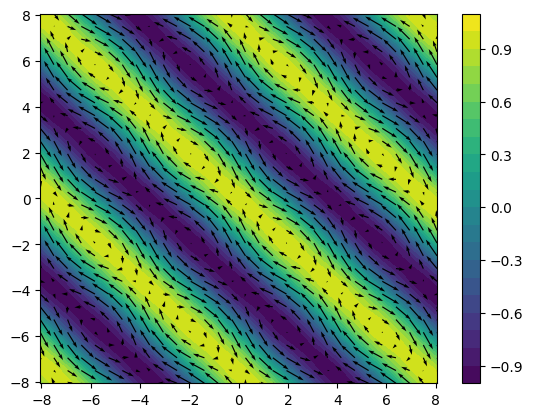

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-3*np.pi/QX, 3*np.pi/QX, 30)
y = np.linspace(-3*np.pi/QX, 3*np.pi/QX, 30)

U, V = np.meshgrid(x,y)
Sx = Spin(sxa,sxb,output_harmonics[:4],U,V) #np.zeros((len(x),len(y)))
Sy = Spin(sya,syb,output_harmonics[:4],U,V)
Sz = Spin(sza,szb,output_harmonics[:4],U,V)
ErrorS = []
#for i in range(len(x)):
  #for j in range(len(y)):
    #Sx[i,j] = Spin(sxa,sxb,output1[:4],x[i],y[j])
    #Sy[i,j] = Spin(sya,syb,output1[:4],x[i],y[j])
    #Sz[i,j] = Spin(sza,szb,output1[:4],x[i],y[j])
    #ErrorS.append(abs(1 - (Sx[i,j]**2 + Sy[i,j]**2 + Sz[i,j]**2)))

S_2 = Sx**2 + Sy**2 + Sz**2

contour = plt.contourf(U,V,Sz,levels = 20)
plt.colorbar(contour)
plt.quiver(U,V, Sx, Sy, scale = 20, width = 0.003)
plt.xlim(-3*np.pi/QX, 3*np.pi/QX)
plt.ylim(-3*np.pi/QX, 3*np.pi/QX)


plt.show()

In [ ]:
np.max(abs(1-S_2))

np.float64(0.0008266947772219702)

In [ ]:
def norm(parameters,nmax):

  arx, ary, arz = np.split(parameters[4:],3)
  Ax, Bx = create_ar(arx,nmax); Ay, By = create_ar(ary,nmax); Az, Bz = create_ar(arz,nmax)

  com = combinations(nmax)

  Posx, Negx = Ar(Ax,Bx)
  Posy, Negy = Ar(Ay,By)
  Posz, Negz = Ar(Az,Bz)

  sxsx = Posx*Negx
  sysy = Posy*Negy
  szsz = Posz*Negz

  #SqS-q terms
  SxSx = np.append(sxsx[0,0],2*np.append(sxsx[1:nmax+1,:1], sxsx[:,1:].reshape(-1)))
  SySy = np.append(sysy[0,0],2*np.append(sysy[1:nmax+1,:1], sysy[:,1:].reshape(-1)))
  SzSz = np.append(szsz[0,0],2*np.append(szsz[1:nmax+1,:1], szsz[:,1:].reshape(-1)))


  coefmatx = B4coef(Ax,Bx,nmax)
  coefmaty = B4coef(Ay,By,nmax)
  coefmatz = B4coef(Az,Bz,nmax)

  S4x = B4xyz(com[0],com[1],coefmatx)
  S4y = B4xyz(com[0],com[1],coefmaty)
  S4z = B4xyz(com[0],com[1],coefmatz)

  S2xy = B2xyz(com[2],com[3],coefmatx,coefmaty)
  S2yz = B2xyz(com[2],com[3],coefmaty,coefmatz)
  S2zx = B2xyz(com[2],com[3],coefmatz,coefmatx)

  s = indexes(nmax)

  SxSy = (
    np.append(Posx[:nmax+1,:1], Posx[:,1:].reshape(-1))*np.append(Negy[:nmax+1,:1], Negy[:,1:].reshape(-1))
    + np.append(Posy[:nmax+1,:1], Posy[:,1:].reshape(-1))*np.append(Negx[:nmax+1,:1], Negx[:,1:].reshape(-1))
  )
  norm = S4x + S4y + S4z + 2*(S2xy + S2yz + S2zx) - 2 * sum(SxSx + SySy + SzSz) + 1
  return np.real(norm)

In [ ]:
norm(output_9harmonics,1)

np.float64(0.01610938271265061)

In [ ]:
norm(output_25harmonics,2)

np.float64(0.016116704344376842)

In [ ]:
norm(output_49harmonics,3)

np.float64(0.016118110689921528)